# Part B - Rama: Supervised Text Classification (Logistic Regression Model with TF-IDF Vectorization)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Logistic Regression Model with TF-IDF Vectorization

In [3]:
# -----------------------------------------------------------
# Import libraries
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

print("All libraries are imported successfully.")

All libraries are imported successfully.


In [4]:
# -----------------------------------------------------------
# Load the IMDB dataset
# -----------------------------------------------------------


df = pd.read_csv("IMDB Dataset.csv")

# Minor dataset inspection
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSample rows:")
df.head()

Dataset shape: (49582, 3)

Column names: ['review', 'sentiment', 'label']

Label distribution:
label
1    24884
0    24698
Name: count, dtype: int64

Sample rows:


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [5]:
# -----------------------------------------------------------
# Train / Test Split — 80% training / 20% testing
# -----------------------------------------------------------

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set size : {len(X_train)}")
print(f"Testing set size  : {len(X_test)}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTesting label distribution:\n{y_test.value_counts()}")

Training set size : 39665
Testing set size  : 9917

Training label distribution:
label
1    19907
0    19758
Name: count, dtype: int64

Testing label distribution:
label
1    4977
0    4940
Name: count, dtype: int64


In [6]:
# -----------------------------------------------------------
# TF-IDF Vectorization — Convert text to numerical features
# -----------------------------------------------------------


tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,       
    ngram_range=(1, 2),       
    sublinear_tf=True,        
    min_df=2,                 
    max_df=0.95,              
    strip_accents="unicode",  
    dtype=np.float32,         
)

print("TF-IDF Vectorizer configured:")
print(f"  max_features  : 50,000")
print(f"  ngram_range   : (1, 2) — unigrams + bigrams")
print(f"  sublinear_tf  : True (log scaling)")
print(f"  min_df        : 2")
print(f"  max_df        : 0.95")

TF-IDF Vectorizer configured:
  max_features  : 50,000
  ngram_range   : (1, 2) — unigrams + bigrams
  sublinear_tf  : True (log scaling)
  min_df        : 2
  max_df        : 0.95


In [7]:
# -----------------------------------------------------------
# Fit TF-IDF and Transform the data
# -----------------------------------------------------------

print("Fitting TF-IDF vectorizer on training data")
start_time = time.time()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

tfidf_time = time.time() - start_time

print(f"\nTF-IDF vectorization complete in {tfidf_time:.2f}s")
print(f"  Training matrix shape : {X_train_tfidf.shape}")
print(f"  Testing matrix shape  : {X_test_tfidf.shape}")
print(f"  Vocabulary size       : {len(tfidf_vectorizer.vocabulary_)}")
print(f"  Matrix density        : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}")

# Sample feature names (top unigrams and bigrams)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n  Sample unigrams : {[f for f in feature_names[:10]]}")
print(f"  Sample bigrams  : {[f for f in feature_names if ' ' in f][:10]}")

Fitting TF-IDF vectorizer on training data

TF-IDF vectorization complete in 32.81s
  Training matrix shape : (39665, 50000)
  Testing matrix shape  : (9917, 50000)
  Vocabulary size       : 50000
  Matrix density        : 0.4789%

  Sample unigrams : ['00', '000', '000 000', '000 to', '007', '01', '02', '10', '10 000', '10 10']
  Sample bigrams  : ['000 000', '000 to', '10 000', '10 10', '10 15', '10 and', '10 because', '10 bethany', '10 br', '10 but']


In [8]:
# -----------------------------------------------------------
# Building the Logistic Regression model
# -----------------------------------------------------------


lr_model = LogisticRegression(
    C=1.0,                        
    solver="lbfgs",               
    max_iter=1000,                
    class_weight="balanced",      
    random_state=42,              
    n_jobs=-1,                    
)

print("Logistic Regression model configured:")
print(f"  C (regularisation) : 1.0")
print(f"  Solver             : lbfgs")
print(f"  Max iterations     : 1000")
print(f"  Class weight       : balanced")

Logistic Regression model configured:
  C (regularisation) : 1.0
  Solver             : lbfgs
  Max iterations     : 1000
  Class weight       : balanced


In [9]:
# -----------------------------------------------------------
# Train the model
# -----------------------------------------------------------

print("=" * 60)
print("Training Logistic Regression on IMDB dataset")
print("=" * 60)

start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time

print(f"\nTraining complete!")
print(f"  Training time     : {train_time:.2f}s")
print(f"  Number of features: {X_train_tfidf.shape[1]}")
print(f"  Number of classes : {len(lr_model.classes_)}")
print(f"  Coefficients shape: {lr_model.coef_.shape}")
print(f"  Intercept         : {lr_model.intercept_[0]:.4f}")

Training Logistic Regression on IMDB dataset

Training complete!
  Training time     : 5.85s
  Number of features: 50000
  Number of classes : 2
  Coefficients shape: (1, 50000)
  Intercept         : 0.1599


In [37]:
# -----------------------------------------------------------
# Display  most influential features - Top 20 positive and negative indicators
# -----------------------------------------------------------

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients  = lr_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:][::-1]
top_negative_idx = np.argsort(coefficients)[:20]

print("=" * 60)
print("Top 20 Most Influential Features")
print("=" * 60)

print("\n--- Strongest POSITIVE sentiment indicators ---")
for i, idx in enumerate(top_positive_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (coeff: {coefficients[idx]:+.4f})")

print("\n--- Strongest NEGATIVE sentiment indicators ---")
for i, idx in enumerate(top_negative_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (coeff: {coefficients[idx]:+.4f})")

Top 20 Most Influential Features

--- Strongest POSITIVE sentiment indicators ---
   1. great                     (coeff: +8.3888)
   2. excellent                 (coeff: +6.4646)
   3. perfect                   (coeff: +5.2569)
   4. wonderful                 (coeff: +4.8300)
   5. amazing                   (coeff: +4.6968)
   6. best                      (coeff: +4.4545)
   7. the best                  (coeff: +4.2021)
   8. loved                     (coeff: +4.0904)
   9. brilliant                 (coeff: +4.0436)
  10. fun                       (coeff: +3.9488)
  11. today                     (coeff: +3.9190)
  12. love                      (coeff: +3.8892)
  13. enjoyed                   (coeff: +3.5751)
  14. superb                    (coeff: +3.5482)
  15. hilarious                 (coeff: +3.4122)
  16. enjoyable                 (coeff: +3.3129)
  17. favorite                  (coeff: +3.2995)
  18. well                      (coeff: +3.2952)
  19. especially                (coe

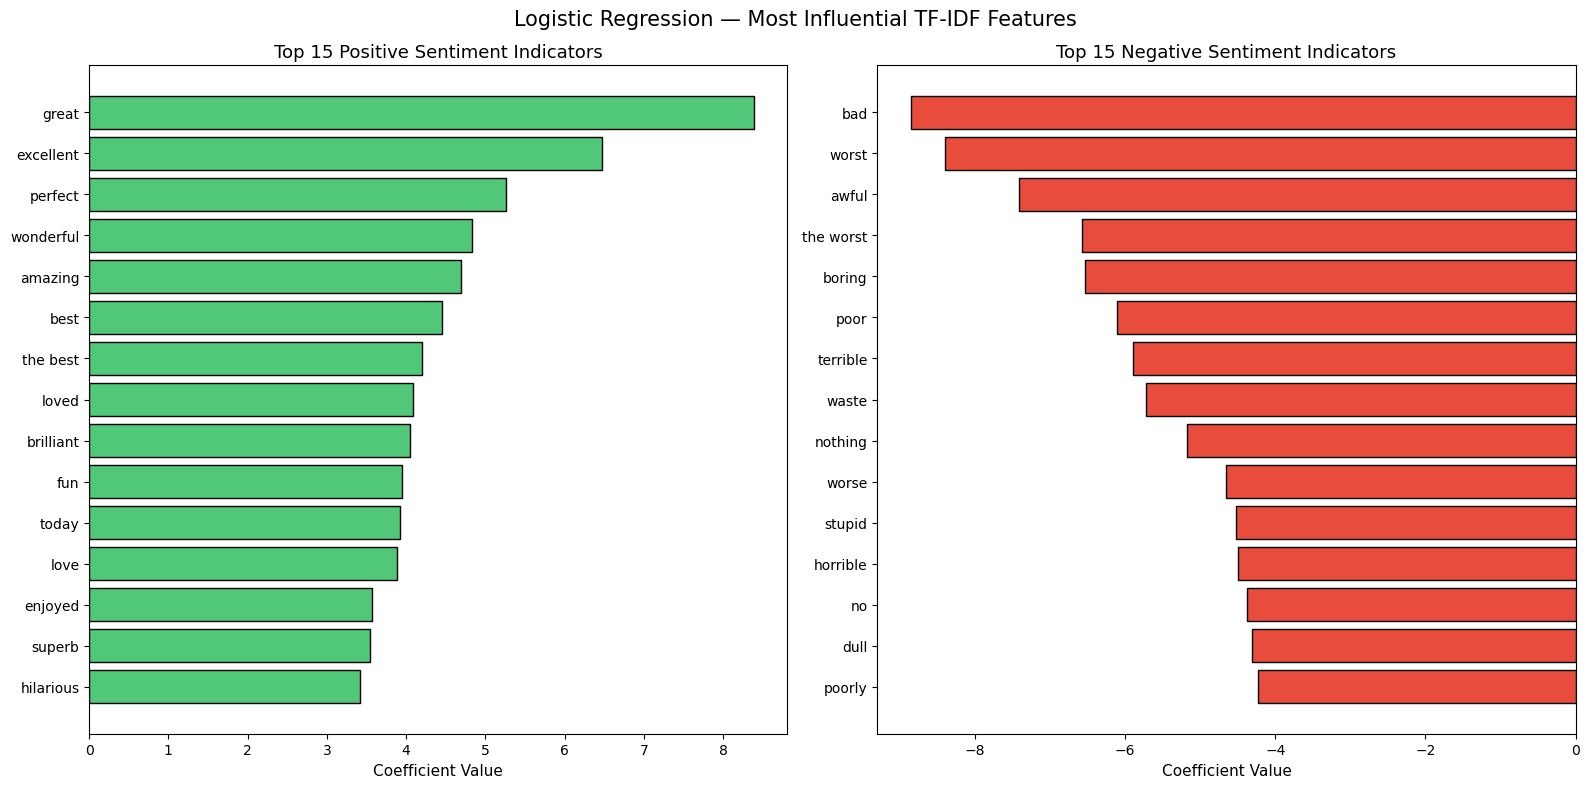

In [11]:
# -----------------------------------------------------------
# Top features Visualisation
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 positive features
top_pos_15 = top_positive_idx[:15]
axes[0].barh(
    [feature_names[i] for i in top_pos_15][::-1],
    [coefficients[i] for i in top_pos_15][::-1],
    color="#50C878",
    edgecolor="black",
)
axes[0].set_title("Top 15 Positive Sentiment Indicators", fontsize=13)
axes[0].set_xlabel("Coefficient Value", fontsize=11)

# Top 15 negative features
top_neg_15 = top_negative_idx[:15]
axes[1].barh(
    [feature_names[i] for i in top_neg_15][::-1],
    [coefficients[i] for i in top_neg_15][::-1],
    color="#E74C3C",
    edgecolor="black",
)
axes[1].set_title("Top 15 Negative Sentiment Indicators", fontsize=13)
axes[1].set_xlabel("Coefficient Value", fontsize=11)

plt.suptitle("Logistic Regression — Most Influential TF-IDF Features", fontsize=15)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Model Evaluation and Results Presentation
# ============================================================

# -----------------------------------------------------------
# Generate predictions
# -----------------------------------------------------------

print("=" * 60)
print("Logistic Regression Model Evaluation on Test Set")
print("=" * 60)

# Predicted class labels
y_pred = lr_model.predict(X_test_tfidf)

# Predicted probabilities (for ROC-AUC)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate all metrics
eval_accuracy  = accuracy_score(y_test, y_pred)
eval_precision = precision_score(y_test, y_pred, average="binary")
eval_recall    = recall_score(y_test, y_pred, average="binary")
eval_f1        = f1_score(y_test, y_pred, average="binary")
eval_roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"\nEvaluation Results:")
print(f"  Accuracy  : {eval_accuracy:.4f} ({eval_accuracy*100:.2f}%)")
print(f"  Precision : {eval_precision:.4f}")
print(f"  Recall    : {eval_recall:.4f}")
print(f"  F1-Score  : {eval_f1:.4f}")
print(f"  ROC-AUC   : {eval_roc_auc:.4f}")

print(f"\nTotal training time: {train_time:.2f}s")
print(f"TF-IDF vectorization time: {tfidf_time:.2f}s")

Logistic Regression Model Evaluation on Test Set

Evaluation Results:
  Accuracy  : 0.9061 (90.61%)
  Precision : 0.8953
  Recall    : 0.9206
  F1-Score  : 0.9078
  ROC-AUC   : 0.9680

Total training time: 5.85s
TF-IDF vectorization time: 32.81s


In [35]:
# -----------------------------------------------------------
# Classification Report
# -----------------------------------------------------------

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative (0)", "Positive (1)"],
    digits=4,
))

Classification Report
              precision    recall  f1-score   support

Negative (0)     0.9177    0.8915    0.9044      4940
Positive (1)     0.8953    0.9206    0.9078      4977

    accuracy                         0.9061      9917
   macro avg     0.9065    0.9061    0.9061      9917
weighted avg     0.9064    0.9061    0.9061      9917



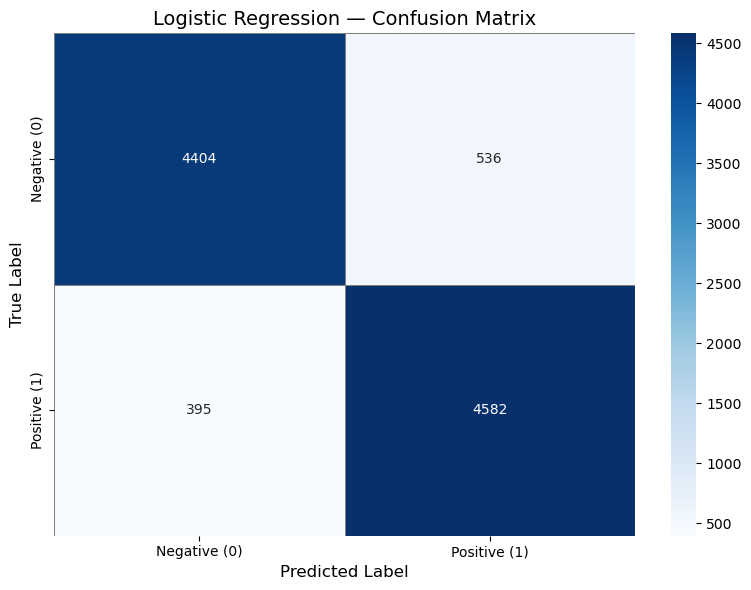


Confusion Matrix Breakdown:
  True Negatives  (TN): 4404
  False Positives (FP): 536
  False Negatives (FN): 395
  True Positives  (TP): 4582


In [14]:
# -----------------------------------------------------------
# Visualisation - Confusion Matrix 
# -----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Logistic Regression — Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

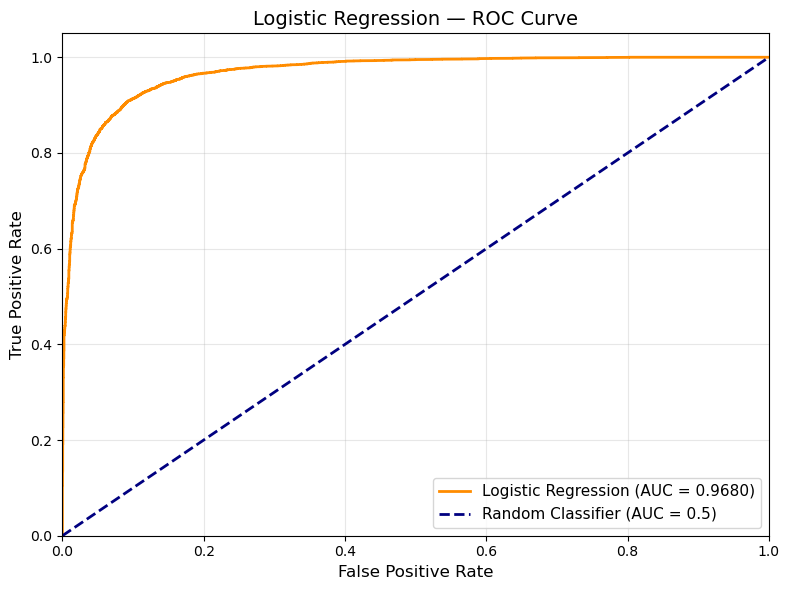

ROC-AUC Score: 0.9680


In [32]:
# -----------------------------------------------------------
# Visualisation - ROC Curve
# -----------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"Logistic Regression (AUC = {eval_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--",
         label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Logistic Regression — ROC Curve", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {eval_roc_auc:.4f}")

In [17]:
# -----------------------------------------------------------
# Sample Predictions
# -----------------------------------------------------------

label_map = {0: "Negative", 1: "Positive"}

print("=" * 60)
print("Sample Predictions from the Test Set")
print("=" * 60)

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=10, replace=False)

for i, idx in enumerate(sample_indices, 1):
    review_text = X_test.iloc[idx]
    true_label  = y_test.iloc[idx]
    pred_label  = y_pred[idx]
    pred_prob   = y_pred_proba[idx]
    status      = "✓" if true_label == pred_label else "✗"

    print(f"\n--- Sample {i} [{status}] ---")
    print(f"  Review   : {review_text[:150]}...")
    print(f"  True     : {label_map[true_label]}")
    print(f"  Predicted: {label_map[pred_label]} (confidence: {pred_prob:.4f})")

Sample Predictions from the Test Set

--- Sample 1 [✓] ---
  Review   : I'm sure this was one of those "WOAH!" attractions in 1982 when Epcot opened, but now it's just silly. The film's message is cliché. The Circle-Vision...
  True     : Negative
  Predicted: Negative (confidence: 0.0720)

--- Sample 2 [✓] ---
  Review   : I liked this movies. Its a another Yash raj film which you know will look good on screen, all character are always nice or very nice with one exceptio...
  True     : Positive
  Predicted: Positive (confidence: 0.9025)

--- Sample 3 [✓] ---
  Review   : The entire thing is very beautiful to look at..the European location shooting was a good idea. The lead actors are attractive. The score is servicable...
  True     : Negative
  Predicted: Negative (confidence: 0.0587)

--- Sample 4 [✓] ---
  Review   : "Children of wax" also shown as "Killing grounds" is an interesting mixture of genres. Some might think the purity of the genre can be only for good b...
  True     :

---

# Part B – Q3: Hyperparameter Tuning (Logistic Regression)


In [18]:
# -----------------------------------------------------------
# Import extra libraries
# -----------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

from scipy.stats import uniform, randint


import warnings
warnings.filterwarnings("ignore")

print("Extra libraries for Hyperparameter Tuning imported successfully.")


Extra libraries for Hyperparameter Tuning imported successfully.


In [19]:
# -----------------------------------------------------------
# Summary table of hyperparameters
# -----------------------------------------------------------

hyperparam_table = pd.DataFrame({
    "Component": [
        "TF-IDF", "TF-IDF", "TF-IDF", "TF-IDF",
        "Logistic Regression", "Logistic Regression", "Logistic Regression",
    ],
    "Hyperparameter": [
        "max_features", "ngram_range", "sublinear_tf", "min_df",
        "C", "solver", "class_weight",
    ],
    "Baseline Value": [
        "50000", "(1,2)", "True", "2",
        "1.0", "lbfgs", "balanced",
    ],
    "Search Range": [
        "[30000, 50000, 70000, 100000]",
        "[(1,1), (1,2), (1,3)]",
        "[True, False]",
        "[1, 2, 3, 5]",
        "[0.01, 0.1, 0.5, 1.0, 5.0, 10.0]",
        "[lbfgs, liblinear, saga]",
        "[None, balanced]",
    ],
    "Impact": [
        "Vocabulary size & dimensionality",
        "Phrase capture (negation handling)",
        "Term frequency scaling",
        "Rare term filtering",
        "Regularisation (bias-variance trade-off)",
        "Optimisation convergence",
        "Class importance weighting",
    ],
})

print("=" * 70)
print("Hyperparameter Summary Table")
print("=" * 70)
print(hyperparam_table.to_string(index=False))
print("=" * 70)

total_combinations = 4 * 3 * 2 * 4 * 6 * 3 * 2
print(f"\nTotal possible combinations: {total_combinations}")

Hyperparameter Summary Table
          Component Hyperparameter Baseline Value                     Search Range                                   Impact
             TF-IDF   max_features          50000    [30000, 50000, 70000, 100000]         Vocabulary size & dimensionality
             TF-IDF    ngram_range          (1,2)            [(1,1), (1,2), (1,3)]       Phrase capture (negation handling)
             TF-IDF   sublinear_tf           True                    [True, False]                   Term frequency scaling
             TF-IDF         min_df              2                     [1, 2, 3, 5]                      Rare term filtering
Logistic Regression              C            1.0 [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] Regularisation (bias-variance trade-off)
Logistic Regression         solver          lbfgs         [lbfgs, liblinear, saga]                 Optimisation convergence
Logistic Regression   class_weight       balanced                 [None, balanced]               Class 

In [20]:

# Hyperparameter Tuning using RandomizedSearchCV

# -----------------------------------------------------------
# Build the sklearn Pipeline - combining TF-IDF and Logistic Regression
# -----------------------------------------------------------


pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        strip_accents="unicode",
        dtype=np.float32,
        max_df=0.95,
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    )),
])

print("Pipeline created:")
print(pipeline)

Pipeline created:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.95,
                                 strip_accents='unicode')),
                ('lr',
                 LogisticRegression(max_iter=1000, n_jobs=-1,
                                    random_state=42))])


In [21]:
# -----------------------------------------------------------
# Define the hyperparameter search space
# -----------------------------------------------------------

param_distributions = {
    # TF-IDF hyperparameters
    "tfidf__max_features":  [30000, 50000, 70000],  
    "tfidf__ngram_range":   [(1, 1), (1, 2), (1, 3)],
    "tfidf__sublinear_tf":  [True, False],
    "tfidf__min_df":        [1, 2, 3, 5],

    # Logistic Regression hyperparameters
    "lr__C":                [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "lr__solver":           ["lbfgs", "liblinear", "saga"],
    "lr__class_weight":     [None, "balanced"],
}

total_combinations = 3 * 3 * 2 * 4 * 6 * 3 * 2
print("Hyperparameter Search Space for RandomizedSearchCV:")
print("=" * 60)
for param, values in param_distributions.items():
    print(f"  {param:<30}: {values}")
print(f"\nTotal possible combinations: {total_combinations}")

Hyperparameter Search Space for RandomizedSearchCV:
  tfidf__max_features           : [30000, 50000, 70000]
  tfidf__ngram_range            : [(1, 1), (1, 2), (1, 3)]
  tfidf__sublinear_tf           : [True, False]
  tfidf__min_df                 : [1, 2, 3, 5]
  lr__C                         : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
  lr__solver                    : ['lbfgs', 'liblinear', 'saga']
  lr__class_weight              : [None, 'balanced']

Total possible combinations: 2592


In [22]:
# -----------------------------------------------------------
# Configure and Run RandomizedSearchCV
# -----------------------------------------------------------

N_ITER = 20  
N_FOLDS = 5  

cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

f1_scorer = make_scorer(f1_score, average="binary")

random_search = RandomizedSearchCV(
    estimator=pipeline,                      
    param_distributions=param_distributions, 
    n_iter=N_ITER,                           
    scoring=f1_scorer,                       
    cv=cv_strategy,                          
    verbose=2,                               
    random_state=42,                         
    refit=True,                              
    n_jobs=1,                                
    return_train_score=True,                 
)

print("=" * 70)
print(f"RandomizedSearchCV — {N_ITER} iterations × {N_FOLDS} folds")
print("=" * 70)
print(f"Scoring metric : F1-score")
print(f"CV strategy    : {N_FOLDS}-fold Stratified Cross-Validation")
print(f"Total fits     : {N_ITER * N_FOLDS} ({N_ITER} combinations × {N_FOLDS} folds)")
print(f"Random state   : 42")
print(f"n_jobs         : 1 (sequential)")
print()

start_time = time.time()
random_search.fit(X_train, y_train)
search_time = time.time() - start_time

print("\n" + "=" * 70)
print("RandomizedSearchCV complete!")
print(f"Total search time: {search_time:.1f}s ({search_time/60:.1f} minutes)")
print("=" * 70)

RandomizedSearchCV — 20 iterations × 5 folds
Scoring metric : F1-score
CV strategy    : 5-fold Stratified Cross-Validation
Total fits     : 100 (20 combinations × 5 folds)
Random state   : 42
n_jobs         : 1 (sequential)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  30.8s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  28.7s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time=  33.5s
[CV] END lr__C=0.1, lr__class_weight=balanced, lr__solver=saga, tfidf__max_features=70000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time= 

In [23]:
# -----------------------------------------------------------
# Display best hyperparameters
# -----------------------------------------------------------

print("=" * 70)
print("Best Hyperparameters by RandomizedSearchCV")
print("=" * 70)
print(f"\nBest Cross-Validated F1-Score: {random_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in random_search.best_params_.items():
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    print(f"  {display_name:<30}: {value}")

Best Hyperparameters by RandomizedSearchCV

Best Cross-Validated F1-Score: 0.9113

Best Hyperparameters:
  TF-IDF: sublinear_tf          : False
  TF-IDF: ngram_range           : (1, 2)
  TF-IDF: min_df                : 2
  TF-IDF: max_features          : 70000
  LR: solver                    : lbfgs
  LR: class_weight              : balanced
  LR: C                         : 10.0


In [24]:
# -----------------------------------------------------------
# Display all trial results in a ranked table
# -----------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)


trials_table = results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_tfidf__max_features",
    "param_tfidf__ngram_range",
    "param_tfidf__sublinear_tf",
    "param_tfidf__min_df",
    "param_lr__C",
    "param_lr__solver",
    "param_lr__class_weight",
    "mean_fit_time",
]].copy()

trials_table.columns = [
    "Rank", "Mean F1 (Test)", "Std F1", "Mean F1 (Train)",
    "max_features", "ngram_range", "sublinear_tf", "min_df",
    "C", "solver", "class_weight", "Fit Time (s)",
]


trials_table = trials_table.sort_values("Rank").reset_index(drop=True)


trials_table["Mean F1 (Test)"]  = trials_table["Mean F1 (Test)"].apply(lambda x: f"{x:.4f}")
trials_table["Std F1"]          = trials_table["Std F1"].apply(lambda x: f"{x:.4f}")
trials_table["Mean F1 (Train)"] = trials_table["Mean F1 (Train)"].apply(lambda x: f"{x:.4f}")
trials_table["Fit Time (s)"]    = trials_table["Fit Time (s)"].apply(lambda x: f"{x:.1f}")

print("=" * 70)
print(f"RandomizedSearchCV — All {N_ITER} Trial Results (sorted by rank)")
print("=" * 70)
print(trials_table.to_string(index=False))
print("=" * 70)

RandomizedSearchCV — All 20 Trial Results (sorted by rank)
 Rank Mean F1 (Test) Std F1 Mean F1 (Train)  max_features ngram_range  sublinear_tf  min_df     C    solver class_weight Fit Time (s)
    1         0.9113 0.0020          0.9927         70000      (1, 2)         False       2 10.00     lbfgs     balanced         28.0
    2         0.9096 0.0019          0.9843         50000      (1, 3)         False       5  5.00      saga     balanced         59.9
    3         0.9090 0.0016          0.9928         30000      (1, 2)          True       5 10.00      saga         None         29.2
    4         0.9078 0.0019          0.9896         30000      (1, 2)         False       2 10.00     lbfgs         None         29.3
    5         0.9076 0.0022          0.9899         30000      (1, 2)         False       3 10.00     lbfgs     balanced         30.5
    6         0.9036 0.0013          0.9449         50000      (1, 3)         False       1  1.00      saga     balanced         62.9
   

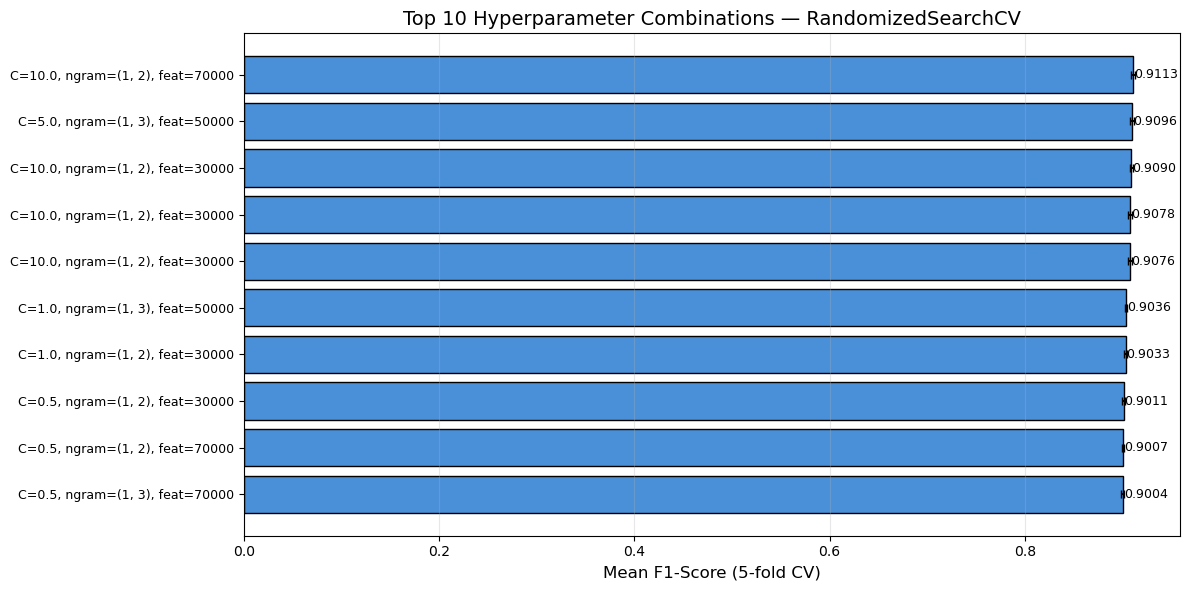

In [25]:
# -----------------------------------------------------------
# Visualisation - Top 10 Hyperparameter Combinations
# -----------------------------------------------------------

top_10 = results_df.nsmallest(10, "rank_test_score")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    range(10),
    top_10["mean_test_score"].values[::-1],
    xerr=top_10["std_test_score"].values[::-1],
    color="#4A90D9",
    edgecolor="black",
    capsize=3,
)

labels = []
for _, row in top_10.iterrows():
    labels.append(
        f"C={row['param_lr__C']}, "
        f"ngram={row['param_tfidf__ngram_range']}, "
        f"feat={row['param_tfidf__max_features']}"
    )

ax.set_yticks(range(10))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("Mean F1-Score (5-fold CV)", fontsize=12)
ax.set_title("Top 10 Hyperparameter Combinations — RandomizedSearchCV", fontsize=14)
ax.grid(axis="x", alpha=0.3)


for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
# -----------------------------------------------------------
# Comparing Baseline vs Best Hyperparameters
# -----------------------------------------------------------

baseline_params = {
    "tfidf__max_features":  50000,
    "tfidf__ngram_range":   (1, 2),
    "tfidf__sublinear_tf":  True,
    "tfidf__min_df":        2,
    "lr__C":                1.0,
    "lr__solver":           "lbfgs",
    "lr__class_weight":     "balanced",
}

best_params = random_search.best_params_

comparison_data = []
for param in baseline_params:
    baseline_val = baseline_params[param]
    best_val = best_params.get(param, "N/A")
    changed = "Yes" if str(baseline_val) != str(best_val) else "No"
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    comparison_data.append({
        "Hyperparameter": display_name,
        "Baseline": str(baseline_val),
        "Best (Tuned)": str(best_val),
        "Changed": changed,
    })

comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("Baseline (Q2) vs Best Hyperparameters (Q3) Comparison")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

Baseline (Q2) vs Best Hyperparameters (Q3) Comparison
      Hyperparameter Baseline Best (Tuned) Changed
TF-IDF: max_features    50000        70000     Yes
 TF-IDF: ngram_range   (1, 2)       (1, 2)      No
TF-IDF: sublinear_tf     True        False     Yes
      TF-IDF: min_df        2            2      No
               LR: C      1.0         10.0     Yes
          LR: solver    lbfgs        lbfgs      No
    LR: class_weight balanced     balanced      No


In [36]:
# -----------------------------------------------------------
# Logistic Regression Model Results (After Hyperparameter Tuning)
# -----------------------------------------------------------


print("=" * 70)
print("Tuned Model Evaluation on Test Set")
print("=" * 70)

best_pipeline = random_search.best_estimator_


y_pred_tuned       = best_pipeline.predict(X_test)
y_pred_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]


tuned_accuracy  = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, average="binary")
tuned_recall    = recall_score(y_test, y_pred_tuned, average="binary")
tuned_f1        = f1_score(y_test, y_pred_tuned, average="binary")
tuned_roc_auc   = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\nResults:")
print(f"  Accuracy  : {tuned_accuracy:.4f} ({tuned_accuracy*100:.2f}%)")
print(f"  Precision : {tuned_precision:.4f}")
print(f"  Recall    : {tuned_recall:.4f}")
print(f"  F1-Score  : {tuned_f1:.4f}")
print(f"  ROC-AUC   : {tuned_roc_auc:.4f}")

#  Classification report
print(f"\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Negative (0)", "Positive (1)"],
    digits=4,
))

Tuned Model Evaluation on Test Set

Results:
  Accuracy  : 0.9123 (91.23%)
  Precision : 0.9067
  Recall    : 0.9198
  F1-Score  : 0.9132
  ROC-AUC   : 0.9714

Classification Report:
              precision    recall  f1-score   support

Negative (0)     0.9180    0.9047    0.9113      4940
Positive (1)     0.9067    0.9198    0.9132      4977

    accuracy                         0.9123      9917
   macro avg     0.9124    0.9122    0.9123      9917
weighted avg     0.9124    0.9123    0.9123      9917



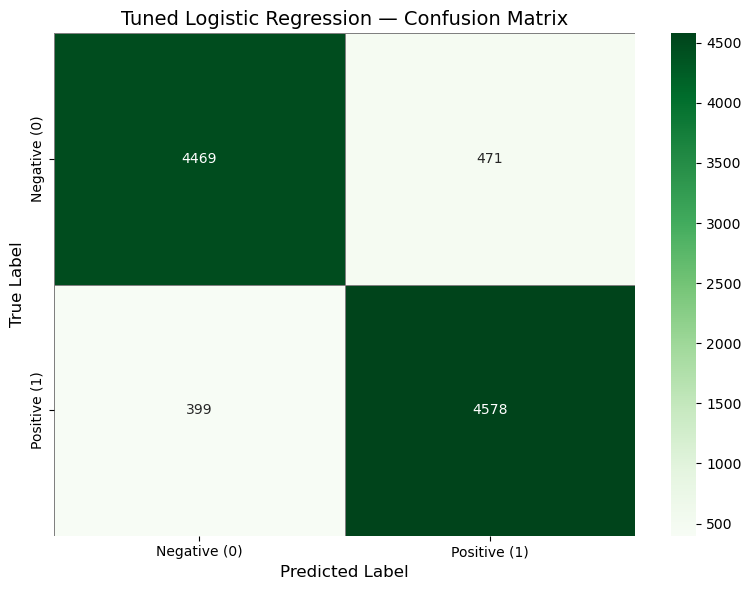

Confusion Matrix Breakdown:
  True Negatives  (TN): 4469
  False Positives (FP): 471
  False Negatives (FN): 399
  True Positives  (TP): 4578


In [28]:
# -----------------------------------------------------------
# Visualization - Confusion matrix for the tuned model
# -----------------------------------------------------------

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Tuned Logistic Regression — Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tuned.ravel()
print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

In [29]:
# -----------------------------------------------------------
# Baseline vs Tuned Performance Comparison 
# -----------------------------------------------------------

baseline_results = {
    "Accuracy":  eval_accuracy,
    "Precision": eval_precision,
    "Recall":    eval_recall,
    "F1-Score":  eval_f1,
    "ROC-AUC":   eval_roc_auc,
}

tuned_results = {
    "Accuracy":  tuned_accuracy,
    "Precision": tuned_precision,
    "Recall":    tuned_recall,
    "F1-Score":  tuned_f1,
    "ROC-AUC":   tuned_roc_auc,
}

# Comparison table
perf_df = pd.DataFrame({
    "Metric": list(baseline_results.keys()),
    "Baseline": [f"{v:.4f}" for v in baseline_results.values()],
    "Tuned": [f"{v:.4f}" for v in tuned_results.values()],
    "Improvement": [
        f"{tuned_results[m] - baseline_results[m]:+.4f}" for m in baseline_results
    ],
})

print("=" * 70)
print("Model Performance Comparison: Baseline (Q2) vs Tuned (Q3)")
print("=" * 70)
print(perf_df.to_string(index=False))
print("=" * 70)

f1_diff = tuned_results["F1-Score"] - baseline_results["F1-Score"]
if f1_diff > 0:
    print(f"\n✓ Hyperparameter tuning IMPROVED F1-score by {f1_diff:.4f}")
elif f1_diff == 0:
    print(f"\n— Hyperparameter tuning produced the SAME F1-score")
else:
    print(f"\n✗ Hyperparameter tuning DECREASED F1-score by {abs(f1_diff):.4f}")
    print("  The baseline configuration may already be near-optimal.")


Model Performance Comparison: Baseline (Q2) vs Tuned (Q3)
   Metric Baseline  Tuned Improvement
 Accuracy   0.9061 0.9123     +0.0062
Precision   0.8953 0.9067     +0.0114
   Recall   0.9206 0.9198     -0.0008
 F1-Score   0.9078 0.9132     +0.0054
  ROC-AUC   0.9680 0.9714     +0.0034

✓ Hyperparameter tuning IMPROVED F1-score by 0.0054


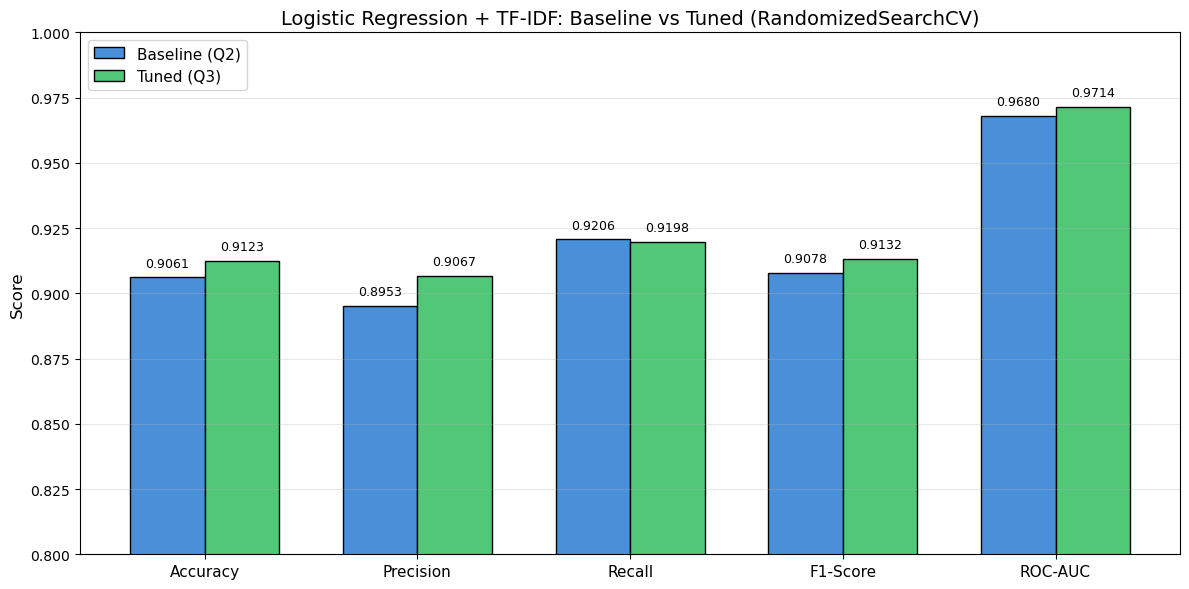

In [30]:
# -----------------------------------------------------------
# Visualization - Bar chart (Baseline vs Tuned performance)
# -----------------------------------------------------------

baseline_results = {
    "Accuracy":  eval_accuracy,
    "Precision": eval_precision,
    "Recall":    eval_recall,
    "F1-Score":  eval_f1,
    "ROC-AUC":   eval_roc_auc,
}

tuned_results = {
    "Accuracy":  tuned_accuracy,
    "Precision": tuned_precision,
    "Recall":    tuned_recall,
    "F1-Score":  tuned_f1,
    "ROC-AUC":   tuned_roc_auc,
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
baseline_vals = [baseline_results[m] for m in metrics]
tuned_vals    = [tuned_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline (Q2)",
               color="#4A90D9", edgecolor="black")
bars2 = ax.bar(x + width/2, tuned_vals, width, label="Tuned (Q3)",
               color="#50C878", edgecolor="black")

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Logistic Regression + TF-IDF: Baseline vs Tuned (RandomizedSearchCV)",
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0.80, 1.0)  
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# -----------------------------------------------------------
# Final Summary
# -----------------------------------------------------------

print("=" * 70)
print("HYPERPARAMETER TUNING SUMMARY (Q3)")
print("=" * 70)
print(f"""
Method Used      : RandomizedSearchCV
Iterations       : {N_ITER} random combinations
Cross-Validation : {N_FOLDS}-fold Stratified CV
Scoring Metric   : F1-score
Total Search Time: {search_time:.1f}s ({search_time/60:.1f} minutes)

Best CV F1-Score : {random_search.best_score_:.4f}

Best Hyperparameters Found:""")
for param, value in random_search.best_params_.items():
    display_name = param.replace("tfidf__", "TF-IDF: ").replace("lr__", "LR: ")
    print(f"  {display_name:<30}: {value}")

print(f"""
Test Set Performance (Tuned Model):
  Accuracy  : {tuned_accuracy:.4f}
  Precision : {tuned_precision:.4f}
  Recall    : {tuned_recall:.4f}
  F1-Score  : {tuned_f1:.4f}
  ROC-AUC   : {tuned_roc_auc:.4f}
""")
print("=" * 70)

HYPERPARAMETER TUNING SUMMARY (Q3)

Method Used      : RandomizedSearchCV
Iterations       : 20 random combinations
Cross-Validation : 5-fold Stratified CV
Scoring Metric   : F1-score
Total Search Time: 4921.1s (82.0 minutes)

Best CV F1-Score : 0.9113

Best Hyperparameters Found:
  TF-IDF: sublinear_tf          : False
  TF-IDF: ngram_range           : (1, 2)
  TF-IDF: min_df                : 2
  TF-IDF: max_features          : 70000
  LR: solver                    : lbfgs
  LR: class_weight              : balanced
  LR: C                         : 10.0

Test Set Performance (Tuned Model):
  Accuracy  : 0.9123
  Precision : 0.9067
  Recall    : 0.9198
  F1-Score  : 0.9132
  ROC-AUC   : 0.9714

